In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [ ]:
df=pd.read_csv("/content/Used_Car_Preprocessing_Dataset.csv")

,Car_ID,Brand,Year,Mileage_Km,Engine_CC,Power_BHP,Fuel_Type,Transmission,City,Seller_Type,Condition,Previous_Owners,Accidents_Reported,Service_Score,Resale_Price_Lakh
0,CAR0001,Skoda,2021,69708,1152,128.8,Diesel,Manual,Lucknow,Individual,Good,1,0,72,6.38
1,CAR0002,Toyota,2020,88881,903,146.5,Diesel,Automatic,Chandigarh,Individual,Good,1,0,87,4.83
2,CAR0003,Volkswagen,2021,43646,1446,185.9,Diesel,Automatic,Hyderabad,Individual,Very Good,2,0,90,7.30
3,CAR0004,Tata,2019,70847,2069,148.8,Petrol,Manual,Lucknow,Individual,Excellent,3,0,66,3.82
4,CAR0005,Tata,2016,101228,1657,206.0,Petrol,Automatic,Ahmedabad,Dealer,Very Good,2,0,84,1.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,CAR0316,Mahindra,2014,151557,1186,131.9,Petrol,Automatic,Lucknow,Dealer,Fair,2,0,94,1.20
316,CAR0317,Volkswagen,2020,60512,1308,135.6,Petrol,Automatic,Delhi,Individual,Excellent,1,2,95,5.93
317,CAR0318,Mahindra,2022,76484,1038,139.6,Diesel,Automatic,Delhi,Dealer,Good,1,1,69,5.30
318,CAR0319,Hyundai,2019,125681,1327,164.3,Diesel,Automatic,Delhi,Dealer,Very Good,1,0,59,3.68


In [11]:
df.head()
df.isnull().sum()
df.shape


(320, 15)

In [38]:
df.columns
df.dtypes

,0
Car_ID,object
Brand,object
Year,int64
Mileage_Km,float64
Engine_CC,int64
Power_BHP,float64
Fuel_Type,object
Transmission,object
City,object
Seller_Type,object


In [65]:
## detect and handle outlier
num_cols = ['Year', 'Mileage_Km', 'Engine_CC', 'Power_BHP',
            'Previous_Owners', 'Accidents_Reported', 'Service_Score']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower) | (df[col] > upper)).sum()

    print(col, ":", outliers)

    df[col] = df[col].clip(lower, upper) ## clip/winsorization

Year : 0
Mileage_Km : 0
Engine_CC : 0
Power_BHP : 0
Previous_Owners : 0
Accidents_Reported : 0
Service_Score : 0


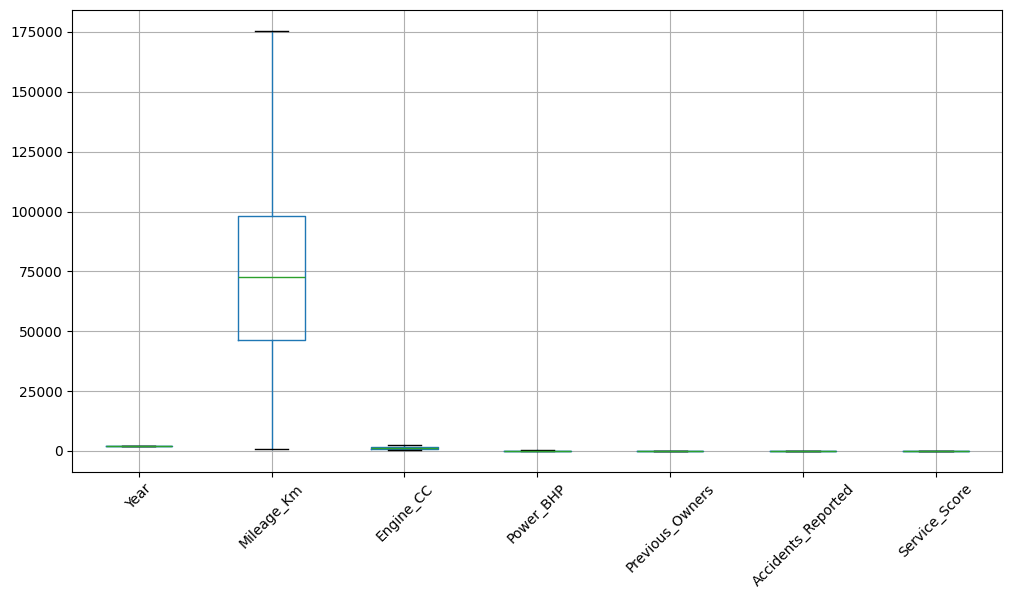

In [67]:
df[num_cols].boxplot(figsize=(12, 6))
plt.xticks(rotation=45)
plt.show()

In [82]:
## encoding

df_encoded = pd.get_dummies(
    df,
    columns=['Car_ID','Brand', 'Transmission', 'City', 'Seller_Type','Fuel_Type','Condition'],
    dtype=int
)

In [86]:

## slpit data
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Resale_Price_Lakh', axis=1)
y = df_encoded['Resale_Price_Lakh']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.dtypes)

Year                     int64
Mileage_Km             float64
Engine_CC                int64
Power_BHP              float64
Previous_Owners        float64
                        ...   
Condition_Excellent      int64
Condition_Fair           int64
Condition_Good           int64
Condition_Poor           int64
Condition_Very Good      int64
Length: 361, dtype: object


In [85]:
## feature scaling

from  sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(X_train)
x_test_scaled=scaler.transform(X_test)
print(x_train_scaled)
print(x_test_scaled)

[[-0.48639121 -0.22590417 -0.32282533 ... -0.86110197 -0.22176638
   1.53896753]
 [ 0.7254448   0.08929593 -0.65690856 ...  1.16130265 -0.22176638
  -0.64978629]
 [-1.39526823  1.11554722 -0.12014816 ...  1.16130265 -0.22176638
  -0.64978629]
 ...
 [ 1.63432182 -1.7119     -0.3718242  ...  1.16130265 -0.22176638
  -0.64978629]
 [-1.09230922 -0.07124305 -0.44086807 ... -0.86110197 -0.22176638
  -0.64978629]
 [ 1.02840381 -0.90372286  0.43443001 ... -0.86110197 -0.22176638
  -0.64978629]]
[[-0.48639121  0.90818319 -1.63243161 ...  1.16130265 -0.22176638
  -0.64978629]
 [ 1.33136281 -0.92689519  0.78633102 ... -0.86110197 -0.22176638
   1.53896753]
 [-1.09230922  0.71014461 -1.41639112 ...  1.16130265 -0.22176638
  -0.64978629]
 ...
 [ 0.11952679 -0.40678958  0.67496994 ... -0.86110197 -0.22176638
  -0.64978629]
 [-0.48639121  0.25523236  0.30302393 ...  1.16130265 -0.22176638
  -0.64978629]
 [ 0.11952679  0.39542491 -1.60347773 ... -0.86110197 -0.22176638
  -0.64978629]]
